# Searching for the Best Model
In this notebook I develop a **credit card fraud detection model** testing several **sklearn classifiers** and **gradient boosting models** with default parameters and then optimizing hyper-parameters to get higher **AUC score**.

The [dataset](https://www.kaggle.com/mlg-ulb/creditcardfraud) contains credit card transactions made by European cardholders in two days in September 2013: a total of **492 frauds out of 284,807 transactions**. Frauds account for **0.172%** of all transactions, which makes the data set highly imbalanced.

**Features:**
- V1, V2 … V28 - numerical features, described in the data set annotation as the output of PCA
- Time - seconds elapsed between each transaction and the first transaction in the data set
- Amount - the transaction amount

**Target value:**
- Class - takes value 1 in case of fraud and 0 otherwise

In [1]:
import os
import random
import joblib

import numpy as np
import pandas as pd

from sklearn.model_selection import StratifiedKFold, cross_val_score, GridSearchCV, train_test_split
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import RobustScaler
from sklearn.pipeline import make_pipeline
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import AdaBoostClassifier, VotingClassifier
from sklearn.svm import SVC
from sklearn.base import BaseEstimator, TransformerMixin, RegressorMixin, clone

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

import optuna
from optuna.samplers import TPESampler

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
import warnings
warnings.filterwarnings('ignore')

In [3]:
PATH = '../input/creditcardfraud/creditcard.csv'

In [4]:
SEED = 0
N_FOLDS = 3

## Functions

In [5]:
def set_seed(seed=42):
    """Utility function to use for reproducibility.
    :param seed: Random seed
    :return: None
    """
    np.random.seed(seed)
    random.seed(seed)
    # tf.random.set_seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    os.environ['TF_DETERMINISTIC_OPS'] = '1'


def set_display():
    """Function sets display options for charts and pd.DataFrames.
    """
    # Plots display settings
    plt.style.use('fivethirtyeight')
    plt.rcParams['figure.figsize'] = 12, 8
    plt.rcParams.update({'font.size': 14})
    # DataFrame display settings
    pd.set_option('display.max_columns', None)
    pd.set_option('display.max_rows', None)
    pd.options.display.float_format = '{:.4f}'.format


def cv_score(model, x: pd.DataFrame, y: pd.Series, metric: str) -> float:
    """Function computed cross-validation score
    for classification model based on a specified metric.
    :param model: sklearn model instance
    :param x: Original DataFrame with features and target values
    :param y: Target labels
    :param metric: Scoring metric
    :return: Mean CV score
    """
    kf = StratifiedKFold(N_FOLDS, shuffle=True, random_state=SEED)
    score = cross_val_score(model, x, y, scoring=metric, cv=kf, n_jobs=-1)
    return score.mean()

## Exploratory Data Analysis

In [6]:
set_seed()
set_display()

In [7]:
data = pd.read_csv(PATH)
print(f'Data shape: {data.shape}')
data.head()

Data shape: (284807, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0000,-1.3598,-0.0728,2.5363,1.3782,-0.3383,0.4624,0.2396,0.0987,0.3638,0.0908,-0.5516,-0.6178,-0.9914,-0.3112,1.4682,-0.4704,0.2080,0.0258,0.4040,0.2514,-0.0183,0.2778,-0.1105,0.0669,0.1285,-0.1891,0.1336,-0.0211,149.6200,0
1,0.0000,1.1919,0.2662,0.1665,0.4482,0.0600,-0.0824,-0.0788,0.0851,-0.2554,-0.1670,1.6127,1.0652,0.4891,-0.1438,0.6356,0.4639,-0.1148,-0.1834,-0.1458,-0.0691,-0.2258,-0.6387,0.1013,-0.3398,0.1672,0.1259,-0.0090,0.0147,2.6900,0
2,1.0000,-1.3584,-1.3402,1.7732,0.3798,-0.5032,1.8005,0.7915,0.2477,-1.5147,0.2076,0.6245,0.0661,0.7173,-0.1659,2.3459,-2.8901,1.1100,-0.1214,-2.2619,0.5250,0.2480,0.7717,0.9094,-0.6893,-0.3276,-0.1391,-0.0554,-0.0598,378.6600,0
3,1.0000,-0.9663,-0.1852,1.7930,-0.8633,-0.0103,1.2472,0.2376,0.3774,-1.3870,-0.0550,-0.2265,0.1782,0.5078,-0.2879,-0.6314,-1.0596,-0.6841,1.9658,-1.2326,-0.2080,-0.1083,0.0053,-0.1903,-1.1756,0.6474,-0.2219,0.0627,0.0615,123.5000,0
4,2.0000,-1.1582,0.8777,1.5487,0.4030,-0.4072,0.0959,0.5929,-0.2705,0.8177,0.7531,-0.8228,0.5382,1.3459,-1.1197,0.1751,-0.4514,-0.2370,-0.0382,0.8035,0.4085,-0.0094,0.7983,-0.1375,0.1413,-0.2060,0.5023,0.2194,0.2152,69.9900,0


In [8]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [9]:
data.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.0000,284807.0000,284807.0000,284807.0000,284807.0000,284807.0000,284807.0000,284807.0000,284807.0000,284807.0000,284807.0000,284807.0000,284807.0000,284807.0000,284807.0000,284807.0000,284807.0000,284807.0000,284807.0000,284807.0000,284807.0000,284807.0000,284807.0000,284807.0000,284807.0000,284807.0000,284807.0000,284807.0000,284807.0000,284807.0000,284807.0000
mean,94813.8596,0.0000,0.0000,-0.0000,0.0000,-0.0000,0.0000,-0.0000,-0.0000,-0.0000,0.0000,0.0000,-0.0000,0.0000,0.0000,0.0000,0.0000,-0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,-0.0000,-0.0000,88.3496,0.0017
std,47488.1460,1.9587,1.6513,1.5163,1.4159,1.3802,1.3323,1.2371,1.1944,1.0986,1.0888,1.0207,0.9992,0.9953,0.9586,0.9153,0.8763,0.8493,0.8382,0.8140,0.7709,0.7345,0.7257,0.6245,0.6056,0.5213,0.4822,0.4036,0.3301,250.1201,0.0415
min,0.0000,-56.4075,-72.7157,-48.3256,-5.6832,-113.7433,-26.1605,-43.5572,-73.2167,-13.4341,-24.5883,-4.7975,-18.6837,-5.7919,-19.2143,-4.4989,-14.1299,-25.1628,-9.4987,-7.2135,-54.4977,-34.8304,-10.9331,-44.8077,-2.8366,-10.2954,-2.6046,-22.5657,-15.4301,0.0000,0.0000
25%,54201.5000,-0.9204,-0.5985,-0.8904,-0.8486,-0.6916,-0.7683,-0.5541,-0.2086,-0.6431,-0.5354,-0.7625,-0.4056,-0.6485,-0.4256,-0.5829,-0.4680,-0.4837,-0.4988,-0.4563,-0.2117,-0.2284,-0.5424,-0.1618,-0.3546,-0.3171,-0.3270,-0.0708,-0.0530,5.6000,0.0000
50%,84692.0000,0.0181,0.0655,0.1798,-0.0198,-0.0543,-0.2742,0.0401,0.0224,-0.0514,-0.0929,-0.0328,0.1400,-0.0136,0.0506,0.0481,0.0664,-0.0657,-0.0036,0.0037,-0.0625,-0.0295,0.0068,-0.0112,0.0410,0.0166,-0.0521,0.0013,0.0112,22.0000,0.0000
75%,139320.5000,1.3156,0.8037,1.0272,0.7433,0.6119,0.3986,0.5704,0.3273,0.5971,0.4539,0.7396,0.6182,0.6625,0.4931,0.6488,0.5233,0.3997,0.5008,0.4589,0.1330,0.1864,0.5286,0.1476,0.4395,0.3507,0.2410,0.0910,0.0783,77.1650,0.0000
max,172792.0000,2.4549,22.0577,9.3826,16.8753,34.8017,73.3016,120.5895,20.0072,15.5950,23.7451,12.0189,7.8484,7.1269,10.5268,8.8777,17.3151,9.2535,5.0411,5.5920,39.4209,27.2028,10.5031,22.5284,4.5845,7.5196,3.5173,31.6122,33.8478,25691.1600,1.0000


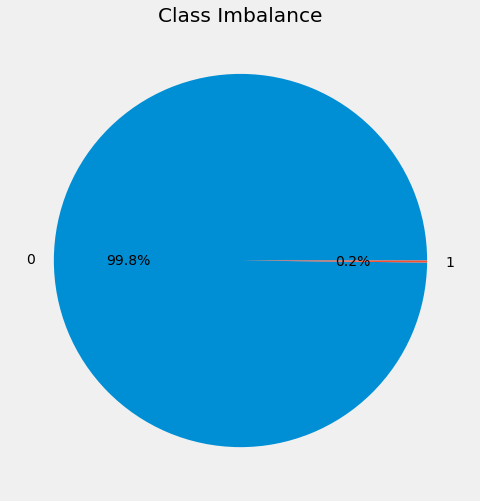

In [10]:
# Target distribution
classes = data['Class'].value_counts(normalize=True)
plt.pie(classes.values, labels=classes.index, autopct='%1.1f%%')
plt.title('Class Imbalance')
plt.show()

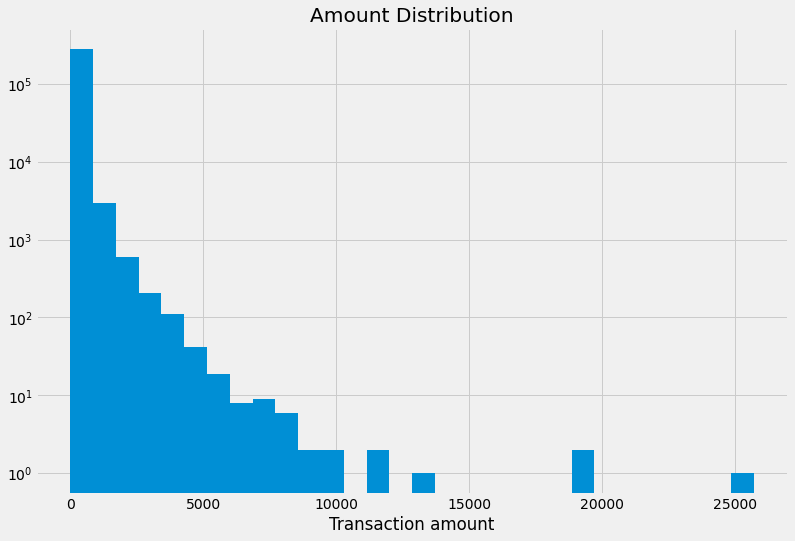

In [11]:
# Amount distribution
plt.hist(data['Amount'], bins=30, log=True)
plt.xlabel('Transaction amount')
plt.title('Amount Distribution')
plt.show()

In [12]:
# Time distribution of transactions
data['Time'].describe()

count   284807.0000
mean     94813.8596
std      47488.1460
min          0.0000
25%      54201.5000
50%      84692.0000
75%     139320.5000
max     172792.0000
Name: Time, dtype: float64

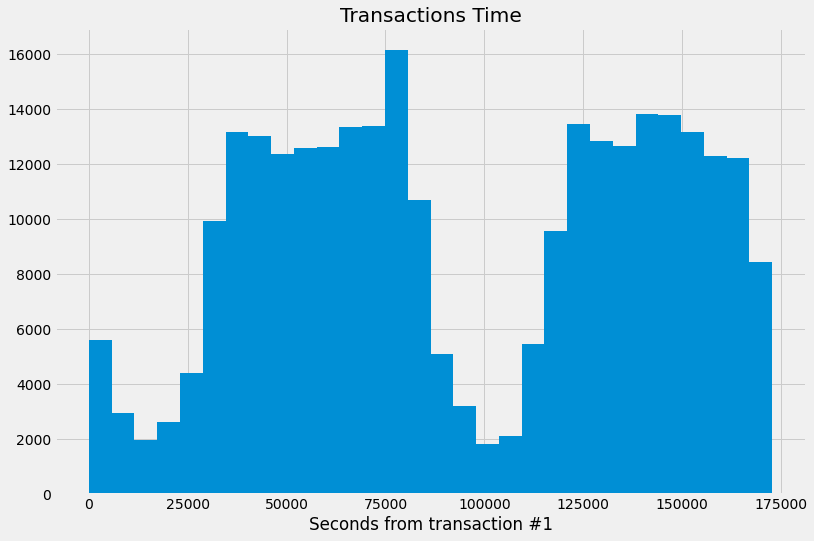

In [13]:
plt.hist(data['Time'], bins=30)
plt.xlabel('Seconds from transaction #1')
plt.title('Transactions Time')
plt.show()

In [14]:
# Feature engineering: temporal features
# Obtain hour from "Time" column, which represents
# seconds passed from the 1st transaction.
# Data set contains transactions for 2 days.
data['hour'] = data['Time'] // 3600
data['hour'] = data['hour'].apply(lambda x: x if x < 24 else x - 24)

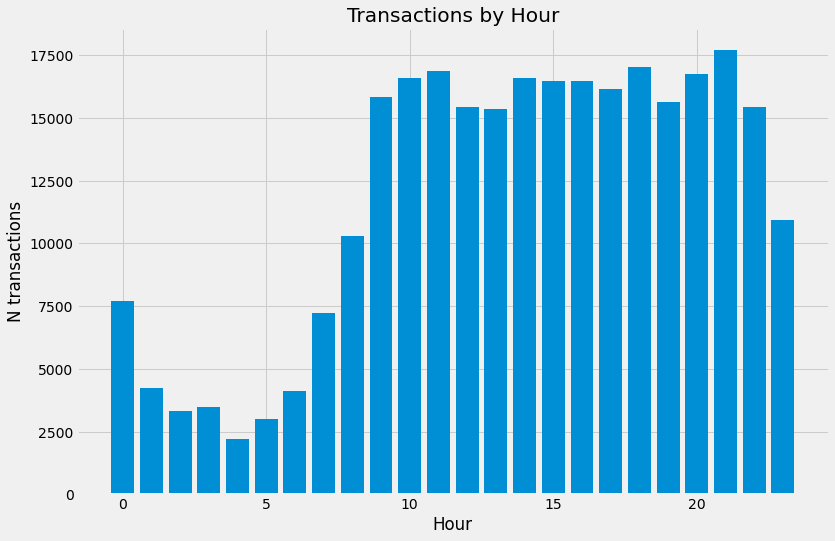

In [15]:
hours = data['hour'].value_counts()
plt.bar(hours.index, hours.values)
plt.xlabel('Hour')
plt.ylabel('N transactions')
plt.title('Transactions by Hour')
plt.show()

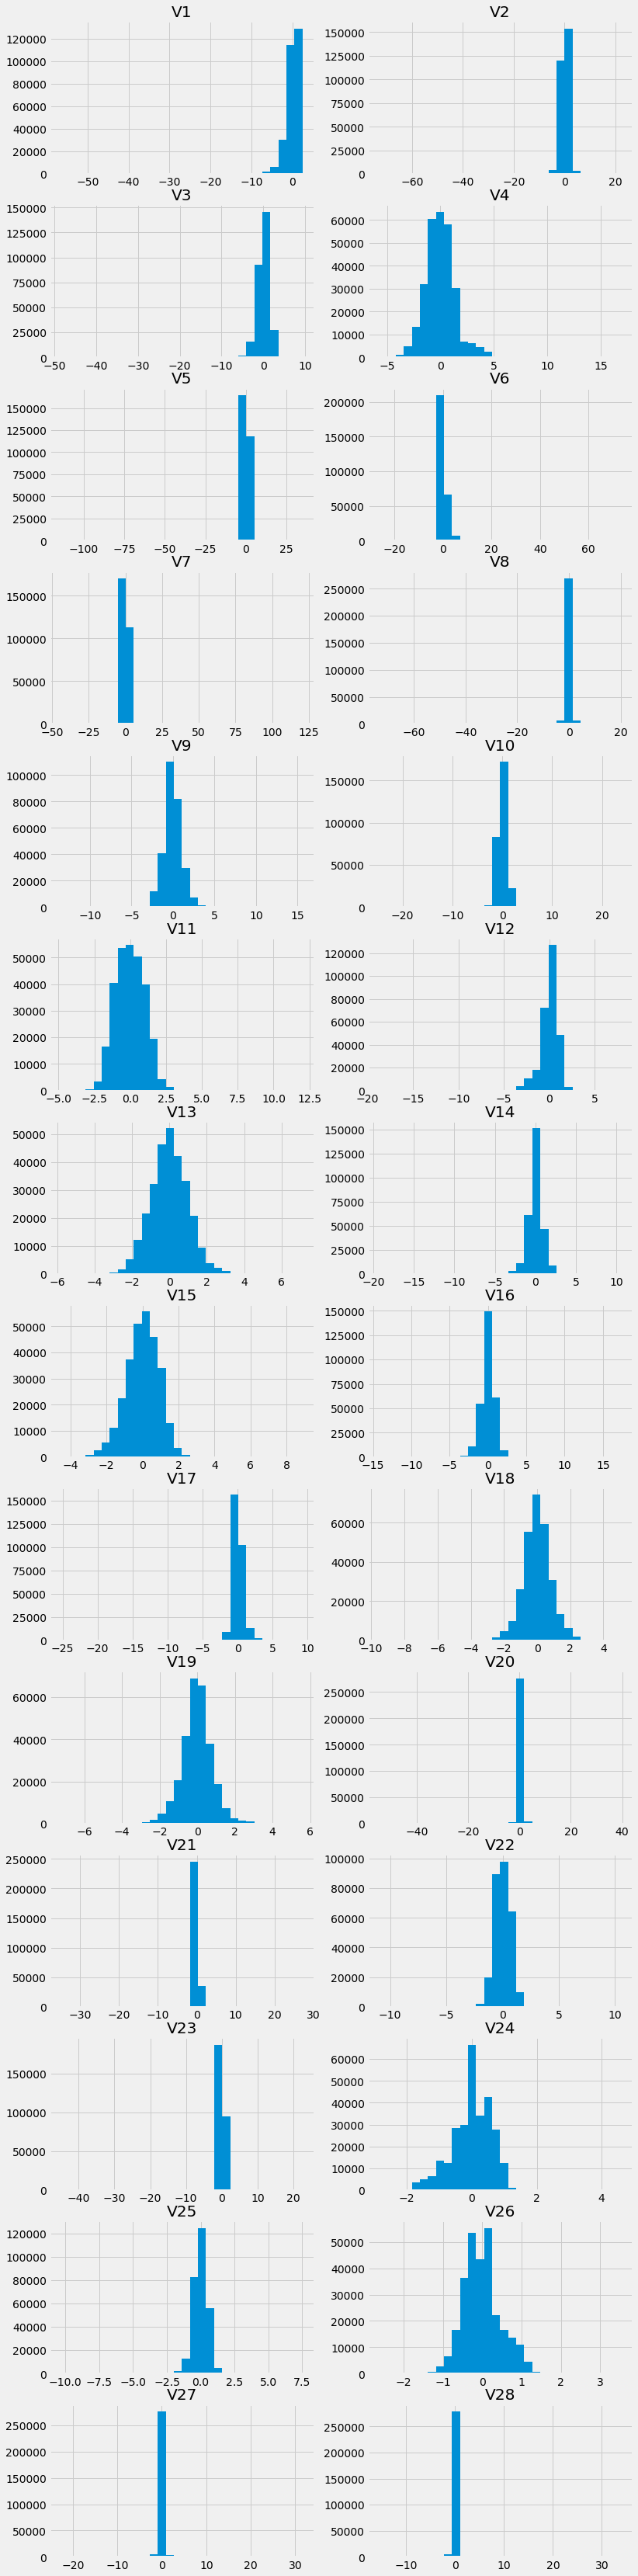

In [16]:
# Distribution of numerical features
num_features = [col for col in data.columns if col.find('V') > -1]

n_cols = 2
n_rows = 14

fig = plt.gcf()
fig.set_size_inches(n_cols * 6, n_rows * 4)

for pos, feature in enumerate(num_features):
    sp = plt.subplot(n_rows, n_cols, pos + 1)
    plt.hist(data[feature], bins=30)
    plt.title(feature)

plt.show()

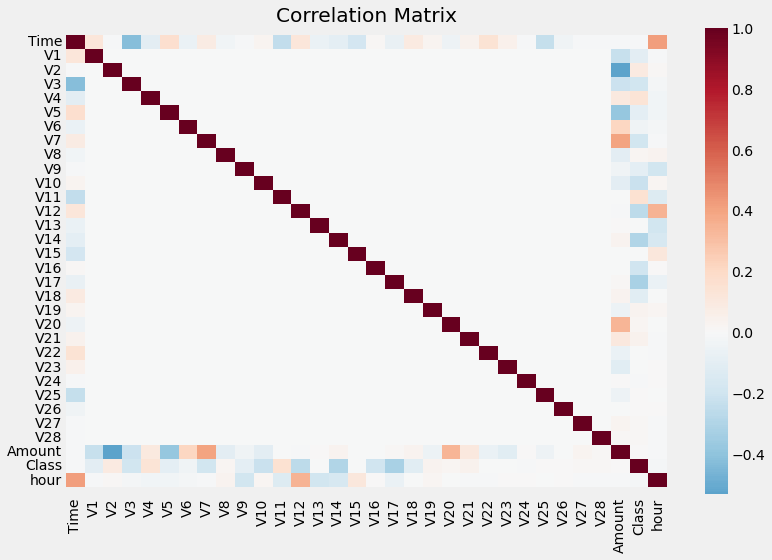

In [17]:
correlation = data.corr()
ax = sns.heatmap(correlation, center=0, cmap='RdBu_r')
l, r = ax.get_ylim()
ax.set_ylim(l + 0.5, r - 0.5)
plt.yticks(rotation=0)
plt.title('Correlation Matrix')
plt.show()

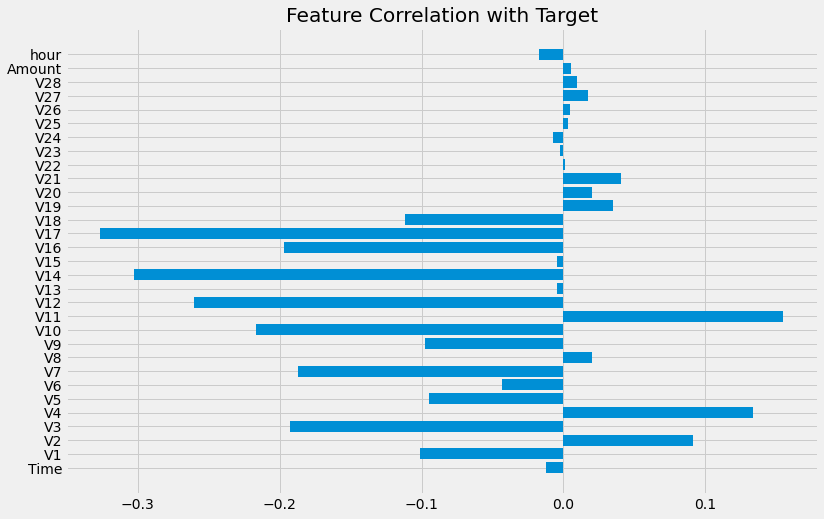

In [18]:
idx = [col for col in data.columns if col != 'Class']
plt.barh(correlation.loc[idx, 'Class'].index, correlation.loc[idx, 'Class'].values)
plt.title('Feature Correlation with Target')
plt.show()

## Cross-Validating sklearn models with default parameters

Tree-based models do not require scaling of input features. Other classification models benefit from data preprocessing:
scaling makes training faster and ensures better convergence. Possible scalers include StandardScaler, MinMaxScaler, PowerTransformer and some others. For this particular problem we will use RobustScaler, where needed. This scaler is recommended for data, which has outliers.

In [19]:
# sklearn classification models
model_gausnb = make_pipeline(RobustScaler(), GaussianNB())
model_aboost = AdaBoostClassifier()
model_svc = make_pipeline(RobustScaler(), SVC())

In [20]:
models = [
    ('Gaussian Naive Bayes', model_gausnb),
    ('Ada boost', model_aboost),
    ('SVC', model_svc),
]

In [21]:
# Input features and target labels
x = data.drop('Class', axis=1)
y = data['Class']

In [22]:
for name, model in models:
    score = cv_score(model, x, y, metric='roc_auc')
    print(f'{name} model AUC score: {score}')

Gaussian Naive Bayes model AUC score: 0.9600382372613776
Ada boost model AUC score: 0.9715352625864292
SVC model AUC score: 0.95495799813328


## Grid-Search for optimal parameters

### Example 1: Improve Naive Bayes classifier

In [23]:
# Create a dictionary of parameters and values to search.
# Since we created a pipeline including scaler and classifier,
# we need to use parameter name with double underscore after model name.
params = {
    'gaussiannb__var_smoothing': [0.001, 0.1, 0.5, 0.9, 0.95, 0.96, 0.97, 0.98, 0.99]
}

# We will use Stratified K-Fold algorithm to train the models
# on several subsets of data and check the AUC score of validation subsets.
kf = StratifiedKFold(N_FOLDS, shuffle=True, random_state=SEED)

# Define Grid-Search
grid = GridSearchCV(model_gausnb, params, cv=kf, scoring='roc_auc',
                    n_jobs=-1, refit=True)

# Display the results
grid.fit(x, y)
print('Best AUC score:', grid.best_score_)
print(grid.best_params_)

# Save the best model.
joblib.dump(grid, 'gaussiannb.pkl')

Best AUC score: 0.9669854843835402
{'gaussiannb__var_smoothing': 0.99}


['gaussiannb.pkl']

### Example 2: Improve AdaBoost classifier

In [24]:
# In this case we use model without preprocessing step.
# Parameters in the dictionary are named the same as in model definition.
# Parameter space is limited to reduce grid-search time.
params = {
    'n_estimators': [50, 60],
    'learning_rate': [0.7, 0.8]
}

grid = GridSearchCV(model_aboost, params, cv=kf, scoring='roc_auc',
                    n_jobs=-1, refit=True)

# Warning: This grid-search takes a long time to complete.
grid.fit(data.drop('Class', axis=1), data['Class'])
print('Best AUC score:', grid.best_score_)
print(grid.best_params_)

joblib.dump(grid, 'adaboost.pkl')

Best AUC score: 0.9748725342400067
{'learning_rate': 0.7, 'n_estimators': 50}


['adaboost.pkl']

## Gradient Boosting with default parameters

In [25]:
# We will use Stratified K-Fold algorithm to train the models
# on several subsets of data and check the AUC score of validation subsets.
kf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)

### Example 1: XGBoost model

In [26]:
scores = []

for train_index, test_index in kf.split(x, y):

    x_train, x_test = x.iloc[train_index, :], x.iloc[test_index, :]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]

    model_xgb = XGBClassifier(objective='binary:logistic')

    model_xgb.fit(x_train, y_train, eval_set=[(x_test, y_test)],
                  eval_metric='auc', early_stopping_rounds=50,
                  verbose=0)

    scores.append(model_xgb.best_score)
    model_xgb.save_model(f'xgboost{len(scores)}.bin')

    print(f'Completed training model {len(scores)}.')

Completed training model 1.
Completed training model 2.
Completed training model 3.


In [27]:
print('XGBoost average AUC score:', np.mean(scores))
for i, score in enumerate(scores):
    print(f'Model {i} AUC score: {score}')

XGBoost average AUC score: 0.9828579999999999
Model 0 AUC score: 0.979914
Model 1 AUC score: 0.982319
Model 2 AUC score: 0.986341


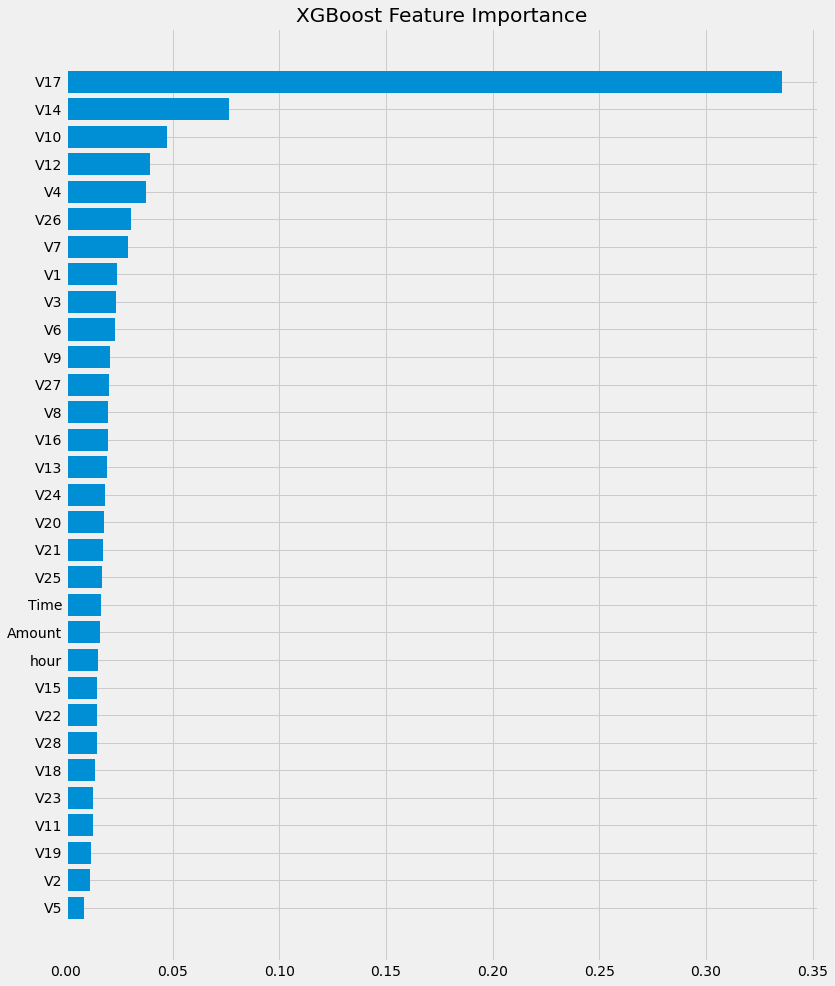

In [28]:
# Display feature importance.
importance = pd.DataFrame({
    'features': x.columns,
    'importance': model_xgb.feature_importances_
})
importance.sort_values(by='importance', inplace=True)

plt.figure(figsize=(12, 16))
plt.barh(importance['features'], importance['importance'])
plt.title('XGBoost Feature Importance')
plt.show()

In [29]:
# Default parameters of the last trained model
model_xgb.get_params

<bound method XGBModel.get_params of XGBClassifier(base_score=0.5, booster='gbtree', colsample_bylevel=1,
              colsample_bynode=1, colsample_bytree=1, enable_categorical=False,
              gamma=0, gpu_id=-1, importance_type=None,
              interaction_constraints='', learning_rate=0.300000012,
              max_delta_step=0, max_depth=6, min_child_weight=1, missing=nan,
              monotone_constraints='()', n_estimators=100, n_jobs=4,
              num_parallel_tree=1, predictor='auto', random_state=0,
              reg_alpha=0, reg_lambda=1, scale_pos_weight=1, subsample=1,
              tree_method='exact', validate_parameters=1, verbosity=None)>

### Example 2: LightGBM model

In [30]:
scores = []

for train_index, test_index in kf.split(x, y):

    x_train, x_test = x.iloc[train_index, :], x.iloc[test_index, :]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]

    model_lgb = LGBMClassifier(objective='binary', metrics='auc')

    model_lgb.fit(x_train, y_train, eval_set=(x_test, y_test),
                  eval_metric='auc', early_stopping_rounds=50,
                  verbose=0)

    scores.append(model_lgb.best_score_['valid_0']['auc'])
    model_lgb.booster_.save_model(f'lgbm{len(scores)}.txt',
                                  num_iteration=model_lgb.best_iteration_)

    print(f'Completed training model {len(scores)}.')

Completed training model 1.
Completed training model 2.
Completed training model 3.


In [31]:
print('LGBM average AUC score:', np.mean(scores))
for i, score in enumerate(scores):
    print(f'Model {i} AUC score: {score}')

LGBM average AUC score: 0.91339684529154
Model 0 AUC score: 0.9082229636107403
Model 1 AUC score: 0.9152333701010795
Model 2 AUC score: 0.9167342021628001


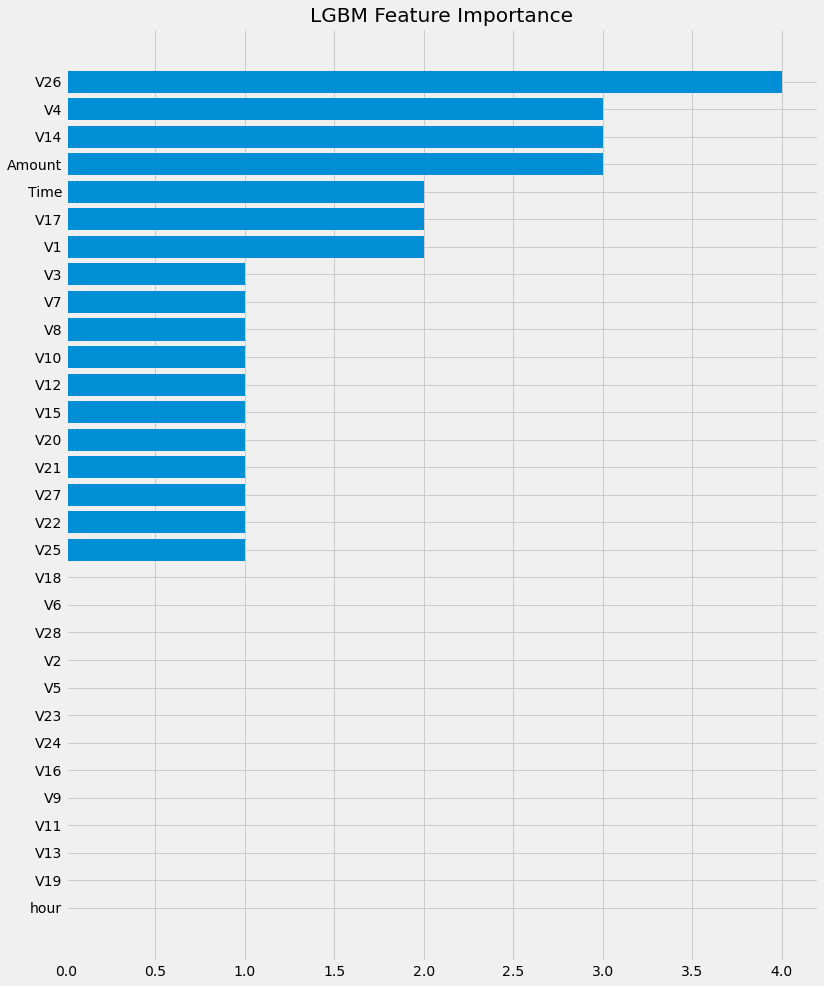

In [32]:
# Display feature importance.
importance = pd.DataFrame({
    'features': x.columns,
    'importance': model_lgb.feature_importances_
})
importance.sort_values(by='importance', inplace=True)

plt.figure(figsize=(12, 16))
plt.barh(importance['features'], importance['importance'])
plt.title('LGBM Feature Importance')
plt.show()

In [33]:
# Default parameters of the last trained model
model_lgb.get_params()

{'boosting_type': 'gbdt',
 'class_weight': None,
 'colsample_bytree': 1.0,
 'importance_type': 'split',
 'learning_rate': 0.1,
 'max_depth': -1,
 'min_child_samples': 20,
 'min_child_weight': 0.001,
 'min_split_gain': 0.0,
 'n_estimators': 100,
 'n_jobs': -1,
 'num_leaves': 31,
 'objective': 'binary',
 'random_state': None,
 'reg_alpha': 0.0,
 'reg_lambda': 0.0,
 'silent': True,
 'subsample': 1.0,
 'subsample_for_bin': 200000,
 'subsample_freq': 0,
 'metrics': 'auc'}

### Example 3: CatBoost model

In [34]:
scores = []

for train_index, test_index in kf.split(x, y):

    x_train, x_test = x.iloc[train_index, :], x.iloc[test_index, :]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]

    model_cb = CatBoostClassifier(eval_metric='AUC')
    model_cb.fit(x_train, y_train, eval_set=[(x_test, y_test)],
                 early_stopping_rounds=20, use_best_model=True,
                 verbose=0)

    scores.append(model_cb.best_score_['validation']['AUC'])
    model_cb.save_model(f'catboost{len(scores)}.cbm')

    print(f'Completed training model {len(scores)}.')

Completed training model 1.
Completed training model 2.
Completed training model 3.


In [35]:
print('Average AUC score:', np.mean(scores))
for i, score in enumerate(scores):
    print(f'Model {i} AUC score: {score}')

Average AUC score: 0.9825325106998571
Model 0 AUC score: 0.984712282520411
Model 1 AUC score: 0.9873779870147918
Model 2 AUC score: 0.9755072625643689


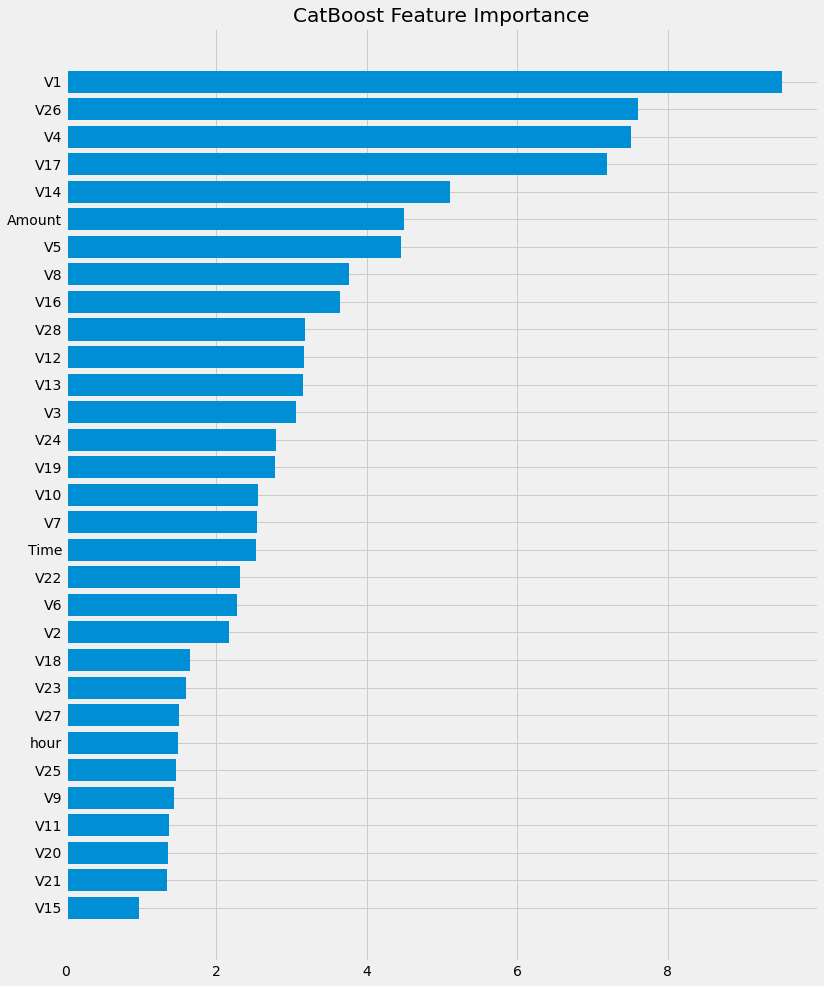

In [36]:
# Display feature importance.
importance = pd.DataFrame({
    'features': x.columns,
    'importance': model_cb.feature_importances_
})
importance.sort_values(by='importance', inplace=True)

plt.figure(figsize=(12, 16))
plt.barh(importance['features'], importance['importance'])
plt.title('CatBoost Feature Importance')
plt.show()

In [37]:
# Parameters of the last trained model
model_cb.get_all_params()

{'nan_mode': 'Min',
 'eval_metric': 'AUC',
 'iterations': 1000,
 'sampling_frequency': 'PerTree',
 'leaf_estimation_method': 'Newton',
 'od_pval': 0,
 'grow_policy': 'SymmetricTree',
 'penalties_coefficient': 1,
 'boosting_type': 'Plain',
 'model_shrink_mode': 'Constant',
 'feature_border_type': 'GreedyLogSum',
 'bayesian_matrix_reg': 0.10000000149011612,
 'l2_leaf_reg': 3,
 'random_strength': 1,
 'od_type': 'Iter',
 'rsm': 1,
 'boost_from_average': False,
 'model_size_reg': 0.5,
 'pool_metainfo_options': {'tags': {}},
 'subsample': 0.800000011920929,
 'use_best_model': True,
 'od_wait': 20,
 'class_names': [0, 1],
 'random_seed': 0,
 'depth': 6,
 'posterior_sampling': False,
 'border_count': 254,
 'classes_count': 0,
 'auto_class_weights': 'None',
 'sparse_features_conflict_fraction': 0,
 'leaf_estimation_backtracking': 'AnyImprovement',
 'best_model_min_trees': 1,
 'model_shrink_rate': 0,
 'min_data_in_leaf': 1,
 'loss_function': 'Logloss',
 'learning_rate': 0.11579500138759612,
 'sc

## Hyper-Parameter Tuning

### Example 1: Improve XGBoost with optuna library

Optuna library requires us to define optimization function, which takes a "trial" object (special class used for searching parameter space), input features and target values. This function is called multiple times
and returns validation score for various parameter combinations.

In [38]:
def objective(trial, x, y):
    """Function performs grid-search for optimal parameters.
    :param trial: optuna trial object
    :param x: Input features
    :param y: Target values
    :return: AUC score
    """
    X_train, X_valid, y_train, y_valid = train_test_split(
        x, y, stratify=y, test_size=.2, random_state=SEED)

    # Parameter space for all tunable arguments.
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 500, 3000, 100),
        'booster': 'gbtree',
        'reg_lambda': trial.suggest_int('reg_lambda', 1, 100),
        'reg_alpha': trial.suggest_int('reg_alpha', 1, 100),
        'subsample': trial.suggest_float('subsample', 0.2, 1.0, step=0.1),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.2, 1.0, step=0.1),
        'max_depth': trial.suggest_int('max_depth', 3, 16),
        'min_child_weight': trial.suggest_int('min_child_weight', 2, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.001, 0.97),
        'gamma': trial.suggest_float('gamma', 0, 20)
    }

    xgb_clf = XGBClassifier(objective='binary:logistic', **params)

    xgb_clf.fit(X_train, y_train, eval_set=[(X_valid, y_valid)],
                eval_metric='auc', early_stopping_rounds=50,
                verbose=False)

    return xgb_clf.best_score

In [39]:
# Initialize an object to perform search for optimal parameters.
study = optuna.create_study(
    sampler=TPESampler(seed=SEED),  # Type of sampling
    direction='maximize',  # Whether the metric should be minimized or maximized.
    study_name='xgb')

# Create lambda function to call grid-search function
# and pass the complete set of input features and target values.
func = lambda trial: objective(trial, x, y)

# Here we call lambda function, which in turn calls optimization function.
study.optimize(func, n_trials=100)

[I 2021-11-27 13:43:07,130] A new study created in memory with name: xgb
[I 2021-11-27 13:43:20,459] Trial 0 finished with value: 0.944714 and parameters: {'n_estimators': 1900, 'reg_lambda': 72, 'reg_alpha': 61, 'subsample': 0.6000000000000001, 'colsample_bytree': 0.5, 'max_depth': 12, 'min_child_weight': 5, 'learning_rate': 0.8651280377578353, 'gamma': 19.273255210020587}. Best is trial 0 with value: 0.944714.
[I 2021-11-27 13:43:56,819] Trial 1 finished with value: 0.907806 and parameters: {'n_estimators': 1400, 'reg_lambda': 80, 'reg_alpha': 53, 'subsample': 0.7, 'colsample_bytree': 1.0, 'max_depth': 3, 'min_child_weight': 2, 'learning_rate': 0.02059162711967562, 'gamma': 16.65239691095876}. Best is trial 0 with value: 0.944714.
[I 2021-11-27 13:44:19,589] Trial 2 finished with value: 0.952197 and parameters: {'n_estimators': 2500, 'reg_lambda': 88, 'reg_alpha': 98, 'subsample': 0.9000000000000001, 'colsample_bytree': 0.6000000000000001, 'max_depth': 13, 'min_child_weight': 3, 'lea

In [40]:
print('Best XGBoost AUC score:', study.best_value)
best_params = study.best_params
print(best_params)

Best XGBoost AUC score: 0.985146
{'n_estimators': 1700, 'reg_lambda': 7, 'reg_alpha': 3, 'subsample': 0.9000000000000001, 'colsample_bytree': 0.5, 'max_depth': 14, 'min_child_weight': 8, 'learning_rate': 0.5808817204452035, 'gamma': 5.553464945760484}


In [41]:
# Save the study.
joblib.dump(study, 'xgb_study.pkl')

['xgb_study.pkl']

In [42]:
# Repeat cross-validation with optimized parameters and save trained models.
scores = []

for train_index, test_index in kf.split(x, y):

    x_train, x_test = x.iloc[train_index, :], x.iloc[test_index, :]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]

    model_xgb = XGBClassifier(objective='binary:logistic', **best_params)

    model_xgb.fit(x_train, y_train, eval_set=[(x_test, y_test)],
                  eval_metric='auc', early_stopping_rounds=50,
                  verbose=0)

    scores.append(model_xgb.best_score)
    model_xgb.save_model(f'xgboost_opt{len(scores)}.bin')

    print(f'Completed training model {len(scores)}.')

Completed training model 1.
Completed training model 2.
Completed training model 3.


In [43]:
print('XGBoost average AUC score:', np.mean(scores))
for i, score in enumerate(scores):
    print(f'Model {i} AUC score: {score}')

XGBoost average AUC score: 0.9792273333333333
Model 0 AUC score: 0.971644
Model 1 AUC score: 0.985554
Model 2 AUC score: 0.980484


### Example 2: Optimizing CatBoost model with built-in grid-search

In [44]:
model_cb = CatBoostClassifier(eval_metric='AUC')

params = {'learning_rate': [0.1, 0.2, 0.3, 0.4],
          'depth': [4, 5, 6, 7]}

grid = model_cb.grid_search(params, X=x, y=y, stratified=True, refit=True)

0:	test: 0.9164339	best: 0.9164339 (0)	total: 43.4ms	remaining: 43.4s
1:	test: 0.9655787	best: 0.9655787 (1)	total: 82.2ms	remaining: 41s
2:	test: 0.9703725	best: 0.9703725 (2)	total: 114ms	remaining: 38s
3:	test: 0.9698728	best: 0.9703725 (2)	total: 146ms	remaining: 36.2s
4:	test: 0.9735179	best: 0.9735179 (4)	total: 181ms	remaining: 36s
5:	test: 0.9735948	best: 0.9735948 (5)	total: 213ms	remaining: 35.3s
6:	test: 0.9731320	best: 0.9735948 (5)	total: 248ms	remaining: 35.2s
7:	test: 0.9717032	best: 0.9735948 (5)	total: 281ms	remaining: 34.8s
8:	test: 0.9734809	best: 0.9735948 (5)	total: 312ms	remaining: 34.3s
9:	test: 0.9785706	best: 0.9785706 (9)	total: 343ms	remaining: 33.9s
10:	test: 0.9793396	best: 0.9793396 (10)	total: 375ms	remaining: 33.7s
11:	test: 0.9800381	best: 0.9800381 (11)	total: 406ms	remaining: 33.5s
12:	test: 0.9802269	best: 0.9802269 (12)	total: 439ms	remaining: 33.3s
13:	test: 0.9803426	best: 0.9803426 (13)	total: 475ms	remaining: 33.4s
14:	test: 0.9805633	best: 0.98

In [45]:
# This grid-search method fits the model, which was passed to it
# and returns a dictionary of grid-search.
# Check that the model is actually fitted.
model_cb.is_fitted()

True

In [46]:
# Save the optimized and trained model and display the parameters.
model_cb.save_model('catboost_opt.cbm')
print('CatBoost optimal parameters:', grid['params'])

CatBoost optimal parameters: {'depth': 6, 'learning_rate': 0.1}


## Conclusions
- The fraud detection algorithm could be further improved by adding more train samples. At present the data is limited to transactions made during 2 days. For more reliable results the data should cover at least one month of transactions or more.
- Synthetic resampling could be applied to address class imbalance issue. However, due to limited number of examples belonging to the positive class (fraud) and the nature of the problem it could be risky to apply such techniques.
- To ensure the prediction reliability several models of various architectures could be combined and process the data independently. As a final step either all identified possible frauds could be unified and passed for investigation or predicted probabilities could be averaged to reduce the false positives.